In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("startdfV1.csv")

In [4]:
import os
import pandas as pd

# Pfad zum Ordner mit den Volumendaten
volume_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/Yukkalab Daten/volumes'

# Liste für die gesammelten Daten
data_list = []

# Initialisiere den Unternehmenszähler
company_no = 1

# Durchlaufe alle Dateien im angegebenen Verzeichnis
for file_name in sorted(os.listdir(volume_path)):
    if file_name.endswith('.csv'):
        # Extrahiere den Unternehmensnamen aus dem Dateinamen (ohne ".csv")
        company_name = file_name[:-4]
        
        # Vollständiger Pfad zur CSV-Datei
        file_path = os.path.join(volume_path, file_name)
        
        # Lade die CSV-Datei
        df_2 = pd.read_csv(file_path)
        
        # Umwandeln der 'date'-Spalte in ein Datumsformat
        df_2['date'] = pd.to_datetime(df_2['date'])
        
        # Aggregiere die Volumendaten auf Monatsbasis
        df_2['year_month'] = df_2['date'].dt.to_period('M')  # Nur das Jahr und den Monat extrahieren
        
        # Summiere das Volumen pro Firma und Monat
        monthly_volume_df = df_2.groupby('year_month').agg({'volume': 'sum'}).reset_index()
        
        # Konvertiere year_month zurück in ein vollständiges Datum (Monatsletzter)
        monthly_volume_df['date'] = monthly_volume_df['year_month'].dt.to_timestamp(how='end').dt.strftime('%Y-%m-%d')
        
        # Füge die Firmeninformationen hinzu
        monthly_volume_df['company'] = company_name
        monthly_volume_df['Company No'] = company_no
        
        # Entferne die year_month-Spalte, falls nicht benötigt
        monthly_volume_df.drop(columns=['year_month'], inplace=True)

        # Füge den DataFrame zur Liste hinzu
        data_list.append(monthly_volume_df)
        
        # Inkrementiere den Unternehmenszähler
        company_no += 1

# Kombiniere alle DataFrames in der Liste zu einem einzigen DataFrame
combined_df = pd.concat(data_list).reset_index(drop=True)

# Sortiere nach Unternehmen und Datum
combined_df.sort_values(by=['company', 'date'], inplace=True)

# Ergebnis anzeigen
print(combined_df.head(20))

# Optional: Speichern als CSV
# combined_df.to_csv("combined_corrected.csv", index=False)

    volume        date company  Company No
0      113  2021-01-31      3i           1
1       77  2021-02-28      3i           1
2      141  2021-03-31      3i           1
3       78  2021-04-30      3i           1
4      206  2021-05-31      3i           1
5      165  2021-06-30      3i           1
6      305  2021-07-31      3i           1
7       93  2021-08-31      3i           1
8       41  2021-09-30      3i           1
9       16  2021-10-31      3i           1
10      97  2021-11-30      3i           1
11     157  2021-12-31      3i           1
12     307  2022-01-31      3i           1
13      83  2022-02-28      3i           1
14     158  2022-03-31      3i           1
15      68  2022-04-30      3i           1
16     313  2022-05-31      3i           1
17     273  2022-06-30      3i           1
18      28  2022-07-31      3i           1
19      24  2022-08-31      3i           1


In [16]:
combined_df.tail()

,volume,date,company,Company No
21825,1984,2023-09-30,zurich_insurance,590
21826,1896,2023-10-31,zurich_insurance,590
21827,3795,2023-11-30,zurich_insurance,590
21828,1866,2023-12-31,zurich_insurance,590
21829,2756,2024-01-31,zurich_insurance,590


In [11]:
df.head()

,Unnamed: 0.1,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Company No,Subfolder Name,Supersector,Company Name Full
0,0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,1,3i_III_GB00B1YW4409,Financial Services,3I GRP
1,1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,2,a2a_A2A_IT0001233417,Utilities,A2A
2,2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,3,aak_ab_AAK_SE0011337708,Food & Beverage,AAK
3,3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,4,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,AALBERTS INDUSTRIES
4,4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,5,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,SABMILLER


In [5]:
# Dein bestehender DataFrame
# Stelle sicher, dass 'combined_df' bereits existiert und eine 'date' Spalte hat
combined_df["date"] = pd.to_datetime(combined_df["date"])

# Erstelle die year_month Spalte
combined_df["year_month"] = combined_df["date"].dt.to_period("M")

# Berechne das maximale Volumen pro Monat und die dazugehörige Firma
max_volume_per_month = combined_df.loc[combined_df.groupby("year_month")["volume"].idxmax(), ["year_month", "volume", "company"]]

# Umbenennen der Spalten für Klarheit
max_volume_per_month.rename(columns={"volume": "max_volume_per_month", "company": "max_volume_company"}, inplace=True)

# Mergen mit dem ursprünglichen DataFrame
combined_df = combined_df.merge(max_volume_per_month, on="year_month", how="left")

# Ergebnis anzeigen
print(combined_df.head())

   volume       date company  Company No year_month  max_volume_per_month  \
0     113 2021-01-31      3i           1    2021-01                279594   
1      77 2021-02-28      3i           1    2021-02                305563   
2     141 2021-03-31      3i           1    2021-03                518278   
3      78 2021-04-30      3i           1    2021-04                387725   
4     206 2021-05-31      3i           1    2021-05                258261   

  max_volume_company  
0        astrazeneca  
1        astrazeneca  
2        astrazeneca  
3        astrazeneca  
4        astrazeneca  


In [6]:
combined_df.tail()

,volume,date,company,Company No,year_month,max_volume_per_month,max_volume_company
21825,1984,2023-09-30,zurich_insurance,590,2023-09,86888,stellantis_nv
21826,1896,2023-10-31,zurich_insurance,590,2023-10,94611,barclays
21827,3795,2023-11-30,zurich_insurance,590,2023-11,88527,barclays
21828,1866,2023-12-31,zurich_insurance,590,2023-12,70020,barclays
21829,2756,2024-01-31,zurich_insurance,590,2024-01,70674,barclays


In [8]:
combined_df.rename(columns={"max_volume_per_month": "max_volume"}, inplace=True)

In [9]:
# Berechnung der 'weight' Spalte mit logarithmischer Transformation
combined_df['log_weight'] = np.log(combined_df['max_volume']) - np.log(combined_df['volume'])

# Behandle Division durch Null oder Fälle, wo das Volumen 0 ist, um Unendlichkeiten oder NaNs zu vermeiden
combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)

combined_df


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_13018/971512047.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['log_weight'].replace([float('inf'), float('-inf')], np.nan, inplace=True)


,volume,date,company,Company No,year_month,max_volume,max_volume_company,log_weight
0,113,2021-01-31,3i,1,2021-01,279594,astrazeneca,7.813706
1,77,2021-02-28,3i,1,2021-02,305563,astrazeneca,8.286106
2,141,2021-03-31,3i,1,2021-03,518278,astrazeneca,8.209507
3,78,2021-04-30,3i,1,2021-04,387725,astrazeneca,8.511343
4,206,2021-05-31,3i,1,2021-05,258261,astrazeneca,7.133850
...,...,...,...,...,...,...,...,...
21825,1984,2023-09-30,zurich_insurance,590,2023-09,86888,stellantis_nv,3.779505
21826,1896,2023-10-31,zurich_insurance,590,2023-10,94611,barclays,3.910027
21827,3795,2023-11-30,zurich_insurance,590,2023-11,88527,barclays,3.149623
21828,1866,2023-12-31,zurich_insurance,590,2023-12,70020,barclays,3.624984


In [10]:
# Function to extract 'capability' from the 'practice' column
def extract_capability(practice):
    parts = practice.split('-')
    if len(parts) > 2:
        return parts[1][:3]  # Extract the first 2-3 letters of the second part
    else:
        return 'Unknown'

# Function to extract 'pillar' from the 'practice' column
def extract_pillar(practice):
    parts = practice.split('-')
    return parts[0][:3]  # Extract the first 2-3 letters of the first part

# Apply these functions to create the new columns
df['capability'] = df['practice'].apply(extract_capability)
df['pillar'] = df['practice'].apply(extract_pillar)

df.head()

,Unnamed: 0.1,Unnamed: 0,date,pos,neu,neg,nf,sentiment,volume,practice,subfolder_name,Company No,Subfolder Name,Supersector,Company Name Full,capability,pillar
0,0,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,1,3i_III_GB00B1YW4409,Financial Services,3I GRP,CCF,BMI
1,1,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,2,a2a_A2A_IT0001233417,Utilities,A2A,CCF,BMI
2,2,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,3,aak_ab_AAK_SE0011337708,Food & Beverage,AAK,CCF,BMI
3,3,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,4,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,AALBERTS INDUSTRIES,CCF,BMI
4,4,0,2021-01-01,0,0,0,0,0.5,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,5,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,SABMILLER,CCF,BMI


In [11]:
# Datentypen optimieren, z.B. für 'Company No'
df['Company No'] = df['Company No'].astype('category')
combined_df['Company No'] = combined_df['Company No'].astype('int32') # Angenommen, dies ist der geeignete Typ

# Datum nur einmal umwandeln und Jahr-Monat extrahieren
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

combined_df['date'] = pd.to_datetime(combined_df['date'])
combined_df['year_month'] = combined_df['date'].dt.to_period('M')

# Spalten vor dem Merge filtern, um den Speicherverbrauch zu reduzieren
df_filtered = df[['Company No', 'year_month', 'Company Name Full', 'date', 'volume',	'practice',	'subfolder_name',	'Subfolder Name',	'Supersector',	'capability',	'pillar']] # und andere notwendige Spalten
combined_df_filtered = combined_df[['Company No', 'year_month', 'log_weight']]

# Merge durchführen
df_merged_volume = pd.merge(df_filtered, combined_df_filtered, on=['Company No', 'year_month'], how='left')

# Ergebnis überprüfen
df_merged_volume.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109692800 entries, 0 to 109692799
Data columns (total 12 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  log_weight         float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(7), period[M](1)
memory usage: 9.8+ GB


In [12]:
df_merged_volume.head(1185)
df = df_merged_volume

In [13]:
df.head()

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,7.813706
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,9.545362
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,7.124993
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,11.442482
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,6.769653


In [14]:
# Replace 'PA0' with 'PAO' in the 'pillar' column
df['pillar'] = df['pillar'].replace('PA0', 'PAO')

# Verify the replacement
print(df['pillar'].unique())


['BMI' 'CE' 'CSE' 'CSG' 'DA' 'DLC' 'DST' 'PAO' 'TI']


In [15]:
df["volume_weighted"] = df["volume"] * df["log_weight"]

In [16]:
df.head(7)

,Company No,year_month,Company Name Full,date,volume,practice,subfolder_name,Subfolder Name,Supersector,capability,pillar,log_weight,volume_weighted
0,1,2021-01,3I GRP,2021-01-01,0,BMI-CCF-Capability Focus,3i_III_GB00B1YW4409,3i_III_GB00B1YW4409,Financial Services,CCF,BMI,7.813706,0.0
1,2,2021-01,A2A,2021-01-01,0,BMI-CCF-Capability Focus,a2a_A2A_IT0001233417,a2a_A2A_IT0001233417,Utilities,CCF,BMI,9.545362,0.0
2,3,2021-01,AAK,2021-01-01,0,BMI-CCF-Capability Focus,aak_ab_AAK_SE0011337708,aak_ab_AAK_SE0011337708,Food & Beverage,CCF,BMI,7.124993,0.0
3,4,2021-01,AALBERTS INDUSTRIES,2021-01-01,0,BMI-CCF-Capability Focus,aalberts_industries_AALB_NL0000852564,aalberts_industries_AALB_NL0000852564,Industrial Goods & Services,CCF,BMI,11.442482,0.0
4,5,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_electrolux_ELUX B_SE0016589170,ab_electrolux_ELUX B_SE0016589170,Food & Beverage,CCF,BMI,6.769653,0.0
5,6,2021-01,SABMILLER,2021-01-01,0,BMI-CCF-Capability Focus,ab_sagax_SAGA B_SE0005127818,ab_sagax_SAGA B_SE0005127818,Food & Beverage,CCF,BMI,9.014733,0.0
6,7,2021-01,ABB,2021-01-01,0,BMI-CCF-Capability Focus,abb_ABBN_CH0012221716,abb_ABBN_CH0012221716,Industrial Goods & Services,CCF,BMI,3.714946,0.0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109692800 entries, 0 to 109692799
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Company No         int64         
 1   year_month         period[M]     
 2   Company Name Full  object        
 3   date               datetime64[ns]
 4   volume             int64         
 5   practice           object        
 6   subfolder_name     object        
 7   Subfolder Name     object        
 8   Supersector        object        
 9   capability         object        
 10  pillar             object        
 11  log_weight         float64       
 12  volume_weighted    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(7), period[M](1)
memory usage: 10.6+ GB


In [18]:
# Convert 'date' to datetime, handling errors
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Convert 'date' to a monthly period
df['month'] = df['date'].dt.to_period('M')

In [19]:
cumulative_volume_per_month = df.groupby(['practice', 'Company Name Full', 'month', 'Supersector', 'capability', 'pillar'])['volume_weighted'].sum().reset_index()

# Rename the 'volume' column to 'cumulative_volume_per_month' for clarity
cumulative_volume_per_month.rename(columns={'volume_weighted': 'cumulative_volume_per_month'}, inplace=True)

In [20]:
cumulative_volume_per_month.head()

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0


In [21]:
# Define the function to assign scores
def assign_score(volume, percentiles):
    if volume == 0:
        return 0
    for i in range(10, 0, -1):  # Start from the highest percentile
        if volume > percentiles.get(f'p{i*10}', np.inf):
            return i
    return 1  # If the volume is not greater than any percentile, return the lowest score

# Calculate percentiles for each group
def calculate_percentiles(group):
    percentiles = np.percentile(group['cumulative_volume_per_month'], [10 * i for i in range(1, 11)])
    return pd.Series(percentiles, index=[f'p{10 * i}' for i in range(1, 11)])

# Apply the function to calculate percentiles for each 'practice', 'Supersector', and 'month' combination
percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()

# Merge the percentiles back into the original DataFrame
merged_df = pd.merge(cumulative_volume_per_month, percentile_df, on=['practice', 'Supersector', 'month'])

# Assign scores using the percentiles
merged_df['score'] = merged_df.apply(lambda row: assign_score(row['cumulative_volume_per_month'], row.to_dict()), axis=1)

# Debugging: Print the percentiles and scores for a specific practice and supersector in a specific month
debug_df = merged_df[(merged_df['practice'] == 'example_practice') & (merged_df['Supersector'] == 'example_supersector') & (merged_df['month'] == 'example_month')]
print(debug_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score', 'p10', 'p20', 'p30', 'p40', 'p50', 'p60', 'p70', 'p80', 'p90', 'p100']])

print(merged_df[['practice', 'Supersector', 'month', 'cumulative_volume_per_month', 'score']])


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_13018/3988397357.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentile_df = cumulative_volume_per_month.groupby(['practice', 'Supersector', 'month']).apply(calculate_percentiles).reset_index()


Empty DataFrame
Columns: [practice, Supersector, month, cumulative_volume_per_month, score, p10, p20, p30, p40, p50, p60, p70, p80, p90, p100]
Index: []
                                 practice         Supersector    month  \
0                BMI-CCF-Capability Focus  Financial Services  2021-01   
1                BMI-CCF-Capability Focus  Financial Services  2021-02   
2                BMI-CCF-Capability Focus  Financial Services  2021-03   
3                BMI-CCF-Capability Focus  Financial Services  2021-04   
4                BMI-CCF-Capability Focus  Financial Services  2021-05   
...                                   ...                 ...      ...   
3261397  TI-SDH-Data Storage Optimization         Real Estate  2023-09   
3261398  TI-SDH-Data Storage Optimization         Real Estate  2023-10   
3261399  TI-SDH-Data Storage Optimization         Real Estate  2023-11   
3261400  TI-SDH-Data Storage Optimization         Real Estate  2023-12   
3261401  TI-SDH-Data Storage Opti

In [22]:
merged_df.head()

,practice,Company Name Full,month,Supersector,capability,pillar,cumulative_volume_per_month,p10,p20,p30,p40,p50,p60,p70,p80,p90,p100,score
0,BMI-CCF-Capability Focus,3I GRP,2021-01,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
1,BMI-CCF-Capability Focus,3I GRP,2021-02,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
2,BMI-CCF-Capability Focus,3I GRP,2021-03,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.501301,10.414120,0
3,BMI-CCF-Capability Focus,3I GRP,2021-04,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0
4,BMI-CCF-Capability Focus,3I GRP,2021-05,Financial Services,CCF,BMI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.852274,0


In [23]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3261402 entries, 0 to 3261401
Data columns (total 18 columns):
 #   Column                       Dtype    
---  ------                       -----    
 0   practice                     object   
 1   Company Name Full            object   
 2   month                        period[M]
 3   Supersector                  object   
 4   capability                   object   
 5   pillar                       object   
 6   cumulative_volume_per_month  float64  
 7   p10                          float64  
 8   p20                          float64  
 9   p30                          float64  
 10  p40                          float64  
 11  p50                          float64  
 12  p60                          float64  
 13  p70                          float64  
 14  p80                          float64  
 15  p90                          float64  
 16  p100                         float64  
 17  score                        int64    
dtypes:

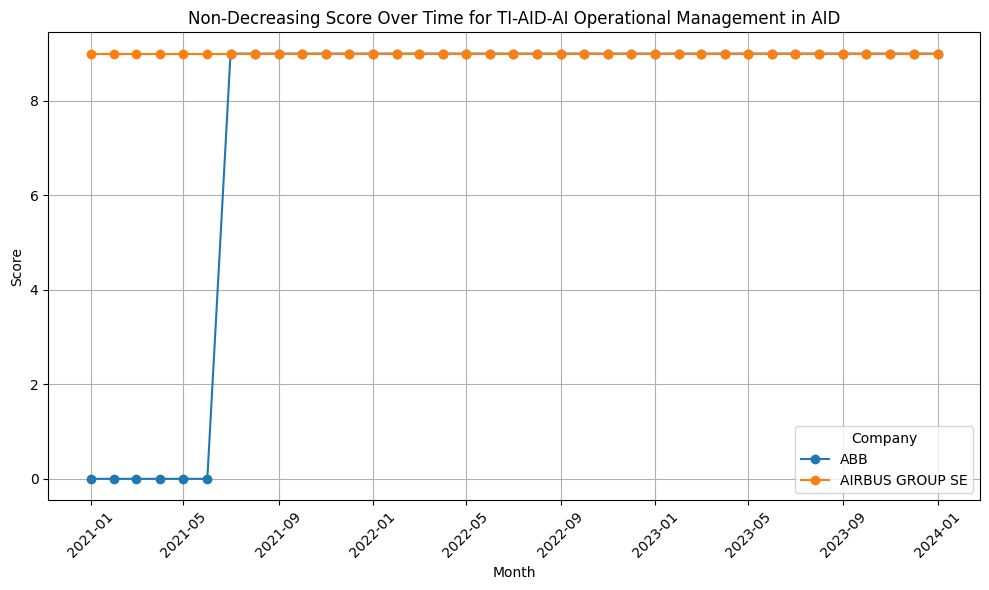

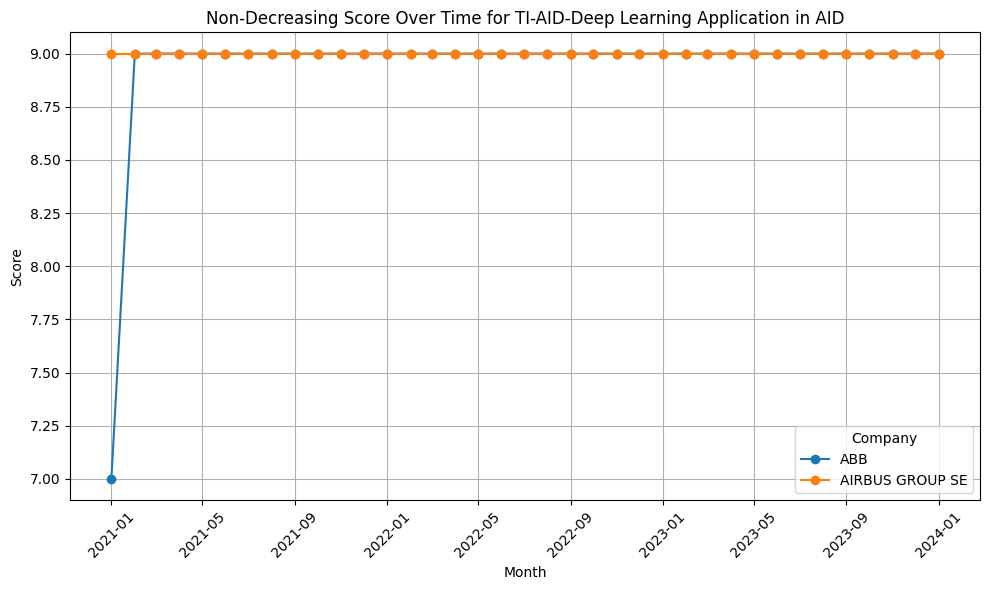

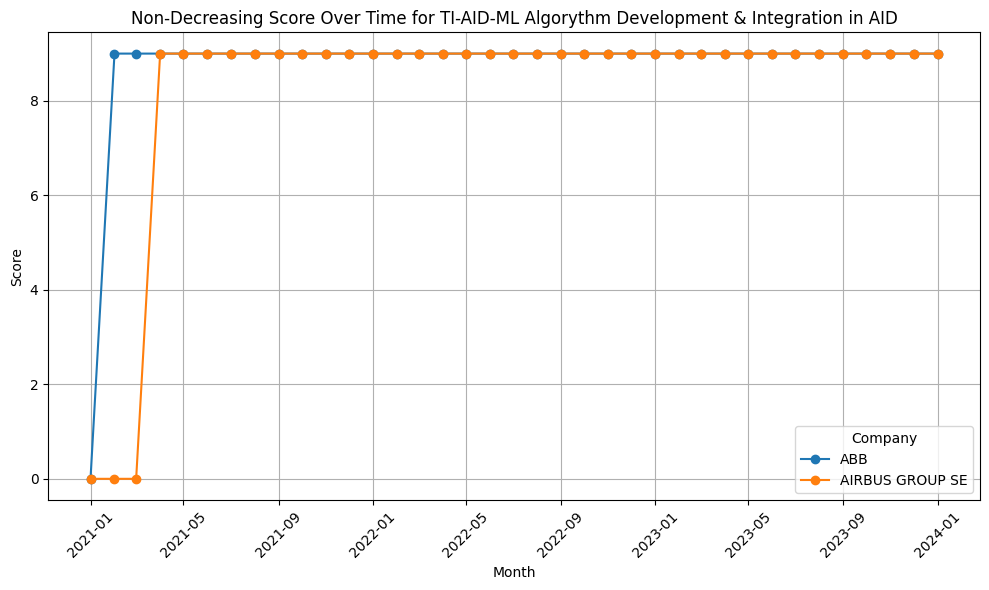

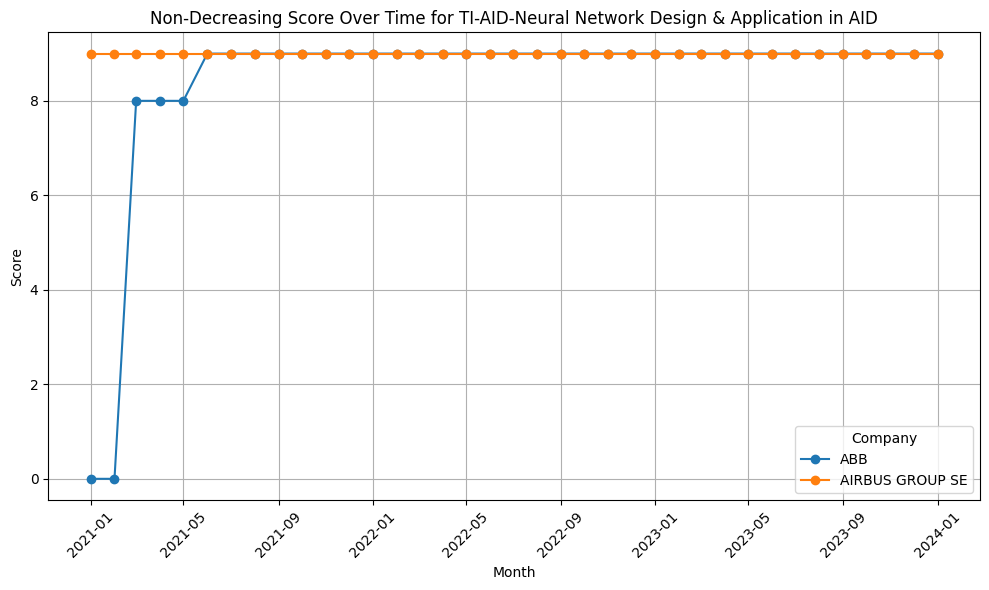

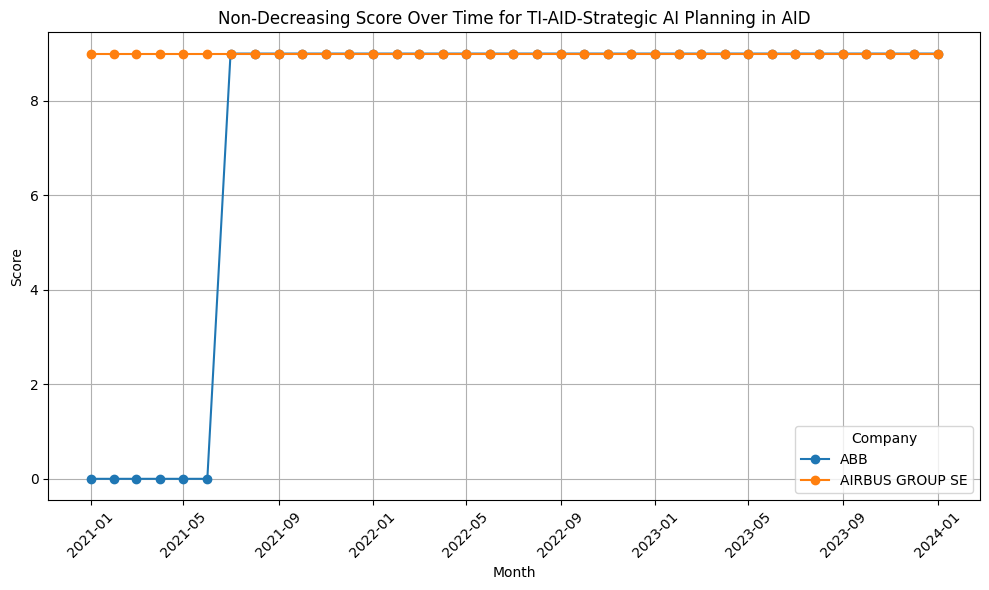

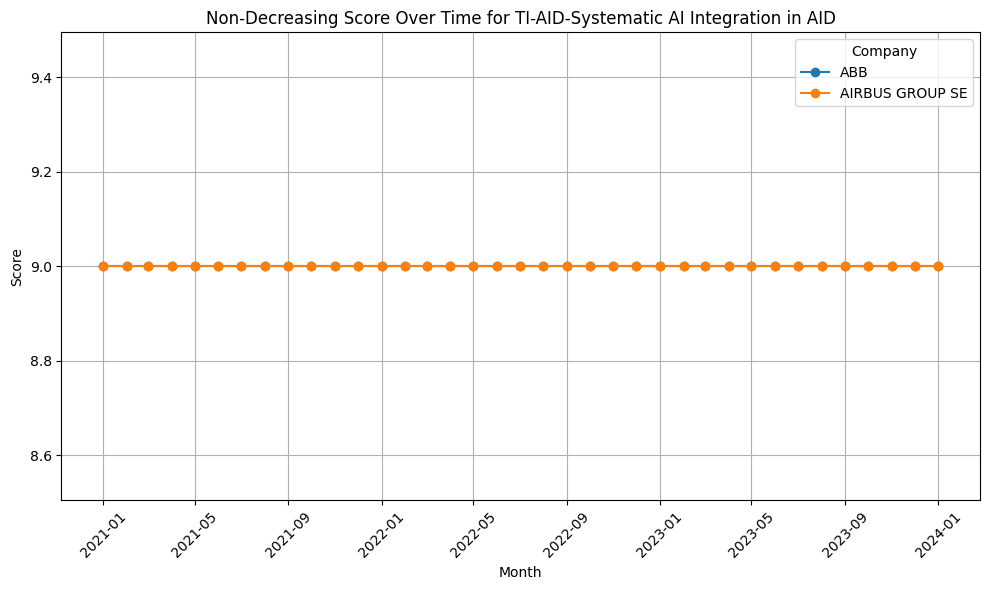

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data frame (assuming 'merged_df' is already loaded)
# merged_df = pd.read_csv('path_to_your_csv_file.csv')

def plot_non_decreasing_scores(df, company1, company2, capability):
    # Filter the DataFrame for the two companies and the specified capability
    filtered_df_BM = df[(df['Company Name Full'].isin([company1, company2])) & (df['capability'] == capability)]
    
    # Pivot the data for plotting with practices
    pivot_df_BM = filtered_df_BM.pivot_table(index=['month', 'practice'], columns='Company Name Full', values='score', aggfunc='mean').unstack('practice')
    
    # Get unique practices
    unique_practices = filtered_df_BM['practice'].unique()
    
    # Create a plot for each practice
    for practice in unique_practices:
        plt.figure(figsize=(10, 6))
        practice_data = pivot_df_BM.xs(practice, level='practice', axis=1)  # Data for the current practice
        
        # 🔥 Convert 'month' from PeriodIndex to DatetimeIndex for plotting
        practice_data.index = practice_data.index.to_timestamp()

        # Ensure scores do not decrease
        practice_data = practice_data.cummax()  # Apply cumulative max to each column

        # Plot lines for each company
        for company in [company1, company2]:
            if company in practice_data.columns:
                plt.plot(practice_data.index, practice_data[company], marker='o', label=f'{company}')
        
        plt.title(f'Non-Decreasing Score Over Time for {practice} in {capability}')
        plt.xlabel('Month')
        plt.ylabel('Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_non_decreasing_scores(merged_df, 'ABB', 'AIRBUS GROUP SE', 'AID')

In [25]:
# Calculate the maximum possible score for each capability
max_scores_per_capability = merged_df.groupby('capability').agg({'practice': 'nunique'}).reset_index()
max_scores_per_capability['max_score_per_capability'] = max_scores_per_capability['practice'] * 10

# Sum the scores for each company, capability, supersector, pillar, and month
capability_scores = merged_df.groupby(['Company Name Full', 'capability', 'Supersector', 'pillar', 'month'])['score'].sum().reset_index()

# Rename the 'score' column to 'maturity_score' for clarity
capability_scores.rename(columns={'score': 'maturity_score'}, inplace=True)

# Merge the maximum scores for each capability back into the capability_scores DataFrame
final_scores = pd.merge(capability_scores, max_scores_per_capability[['capability', 'max_score_per_capability']], on='capability', how='left')

# Select relevant columns for display
final_scores = final_scores[['Company Name Full', 'capability', 'Supersector', 'pillar', 'month', 'maturity_score', 'max_score_per_capability']]

final_scores.head()




,Company Name Full,capability,Supersector,pillar,month,maturity_score,max_score_per_capability
0,3I GRP,AID,Financial Services,TI,2021-01,0,60
1,3I GRP,AID,Financial Services,TI,2021-02,0,60
2,3I GRP,AID,Financial Services,TI,2021-03,0,60
3,3I GRP,AID,Financial Services,TI,2021-04,0,60
4,3I GRP,AID,Financial Services,TI,2021-05,0,60


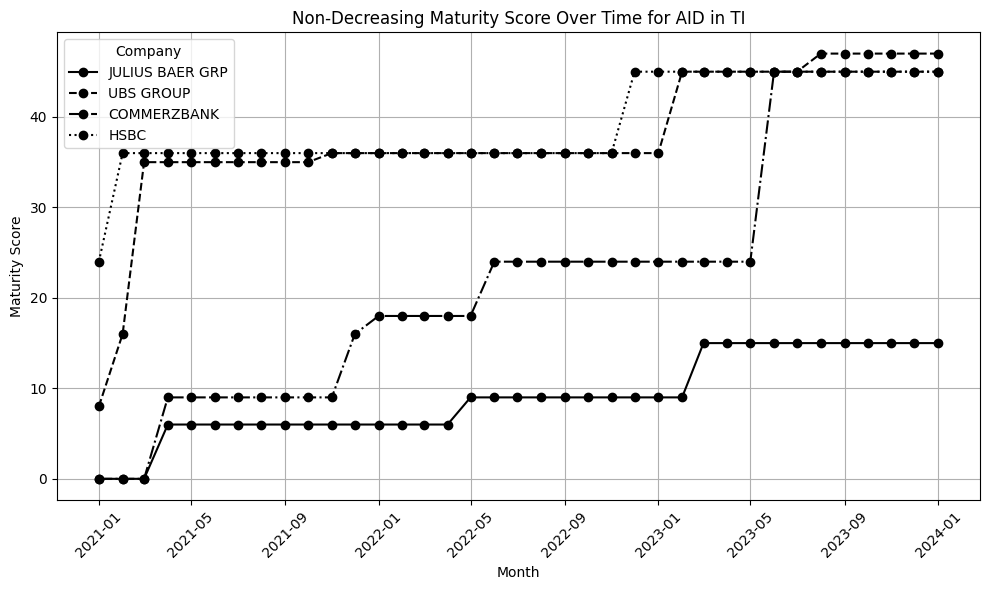

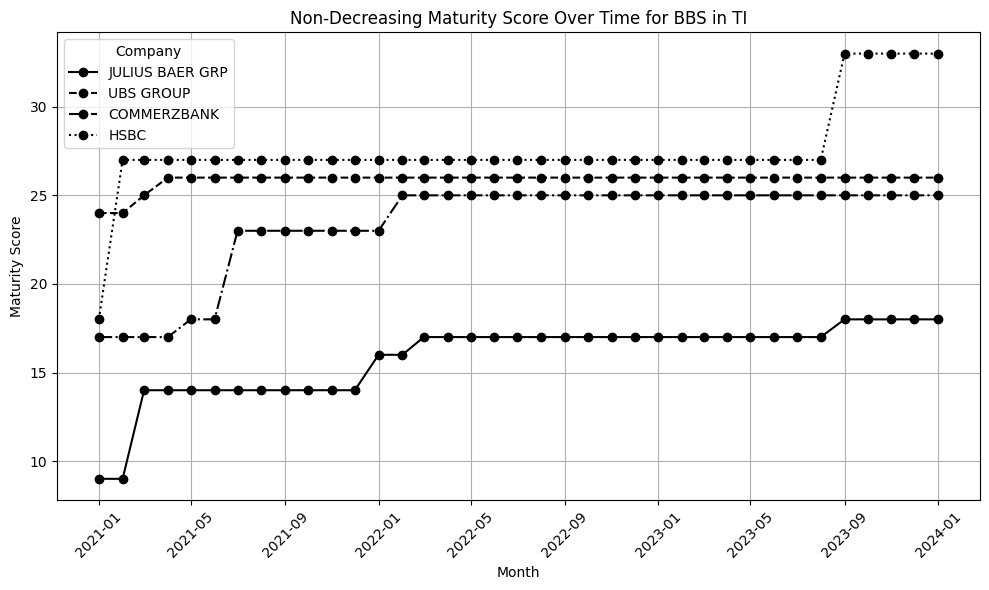

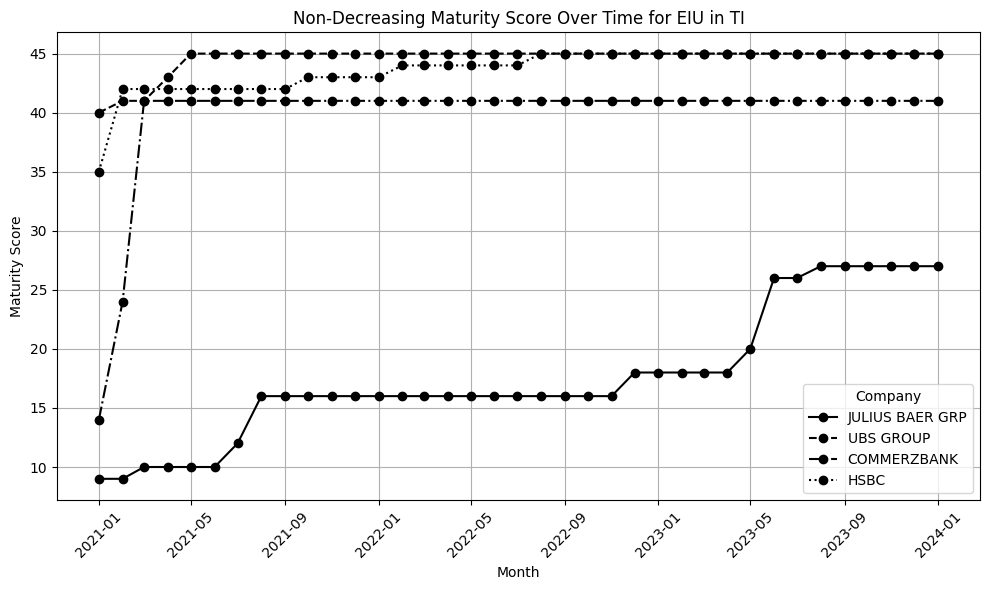

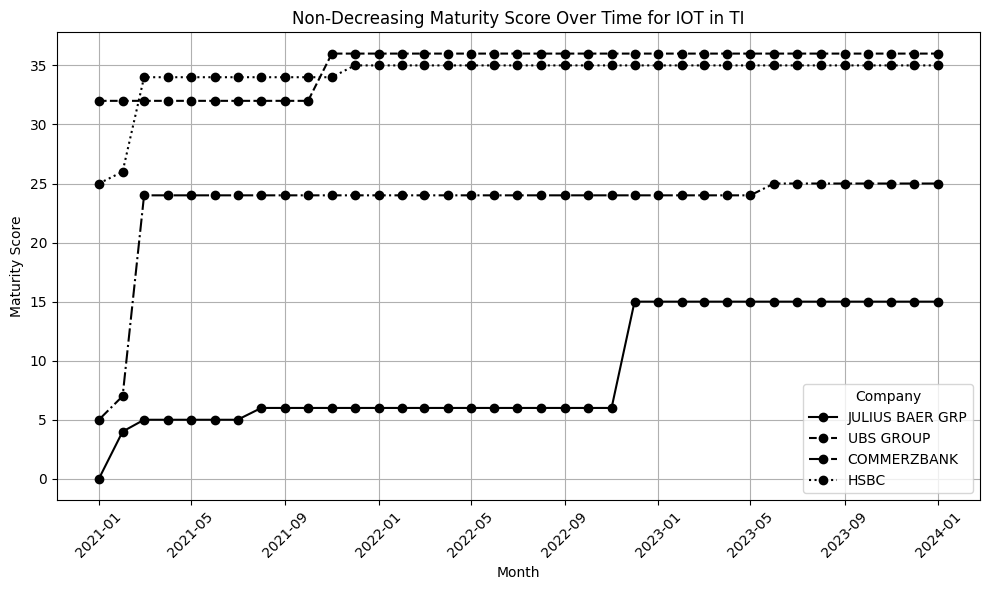

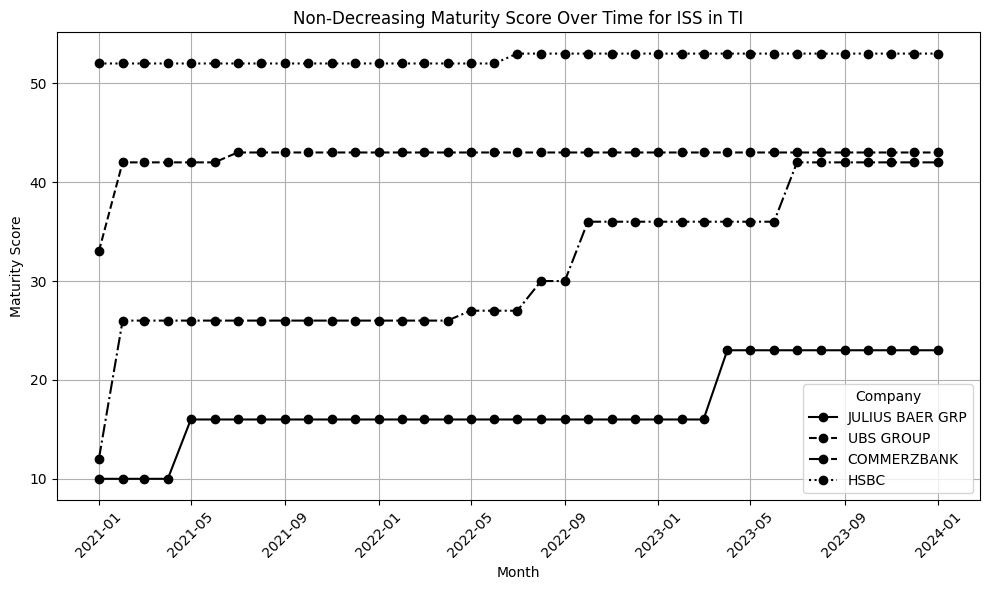

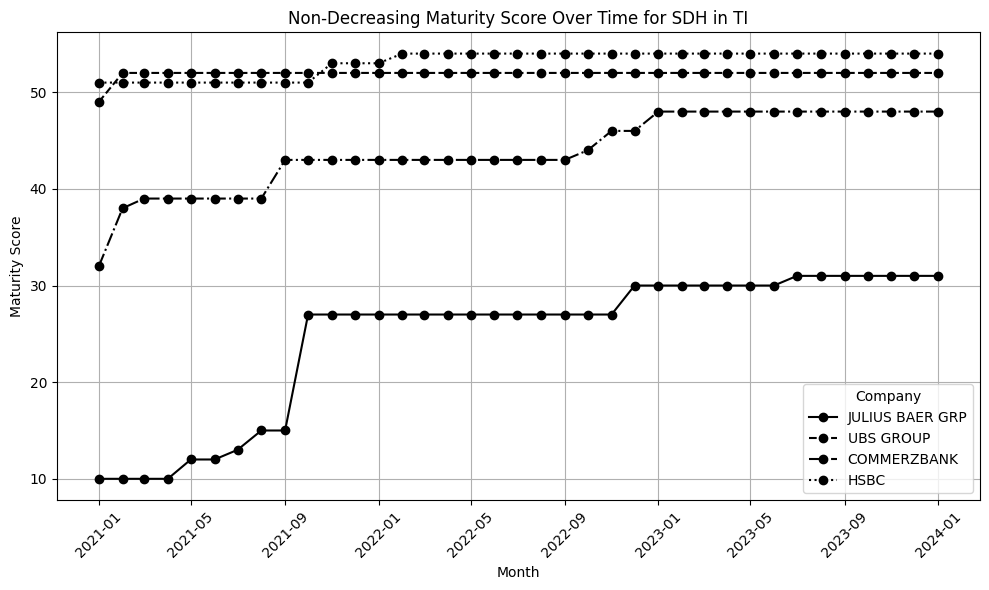

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_capability_scores(df, companies, pillar):
    # Filter the DataFrame for the specified companies and pillar
    filtered_df_BM2 = df[(df['Company Name Full'].isin(companies)) & (df['pillar'] == pillar)]
    
    # Pivot the data for plotting with capabilities
    pivot_df_BM2 = filtered_df_BM2.pivot_table(index=['month', 'capability'], 
                                               columns='Company Name Full', 
                                               values='maturity_score', 
                                               aggfunc='mean').unstack('capability')

    # Reset index to make 'month' a column, then convert it to datetime
    pivot_df_BM2 = pivot_df_BM2.reset_index()
    pivot_df_BM2['month'] = pivot_df_BM2['month'].dt.to_timestamp()  # Convert from Period to Datetime
    pivot_df_BM2.set_index('month', inplace=True)  # Set back as index

    # Get unique capabilities
    unique_capabilities = filtered_df_BM2['capability'].unique()
    
    # Define line styles for the companies
    line_styles = ['-', '--', '-.', ':']
    
    # Ensure there are enough line styles for the number of companies
    line_styles = (line_styles * (len(companies) // len(line_styles) + 1))[:len(companies)]

    # Create a plot for each capability
    for capability in unique_capabilities:
        plt.figure(figsize=(10, 6))
        
        # Extract data for the current capability
        capability_data = pivot_df_BM2.xs(capability, level='capability', axis=1)  

        # Ensure scores do not decrease over time
        capability_data = capability_data.cummax()  

        # Plot lines for each company with different line styles
        for idx, company in enumerate(companies):
            if company in capability_data.columns:
                plt.plot(capability_data.index,  # The index is now in datetime format
                         capability_data[company], 
                         marker='o', label=f'{company}', 
                         color='black', linestyle=line_styles[idx])
        
        plt.title(f'Non-Decreasing Maturity Score Over Time for {capability} in {pillar}')
        plt.xlabel('Month')
        plt.ylabel('Maturity Score')
        plt.legend(title='Company')
        plt.grid(True)
        plt.xticks(rotation=45)  # Rotate dates for better visibility
        plt.tight_layout()
        plt.show()

# Usage example
plot_capability_scores(final_scores, ['JULIUS BAER GRP', 'UBS GROUP', 'COMMERZBANK', 'HSBC'], 'TI')